<img src="https://userweb.fct.unl.pt/~jmc.xavier/MSI/iLogos/nsst.jpg" width="400" height="100">

# DEMI | NOVA SST

## Mecânica dos Sólidos I

## Tração e compressão de barras elásticas e elastoplásticas perfeitas
## Vigas sujeitas à tracção/compressão. Parte III
## Problema 2 <a name="PIV102"></a>

Duas barras de aço temperado com 5 mm de espessura e 50 mm de largura estão ligadas a uma barra de aço macio com 12,5 mm de espessura. O conjunto está submetido a uma força axial de intensidade $P$, como se mostra na figura. Os dois aços têm comportamento elastoplástico com $E = 200$ GPa e tensões de cedência $\sigma_C$ = 700 MPa e $\sigma_C$ = 350 MPa para o aço temperado e para o aço macio respectivamente. A força $P$ é gradualmente aumentada a partir de zero até atingir 500 kN e em seguida regressa novamente a zero. Determine:

[a)](#A) O alongamento máximo que ocorre para o conjunto das três barras.

[b)](#B) As tensões normais máximas nas barras.

[c)](#C) O alongamento residual do conjunto das três barras e as correspondentes tensões residuais.

<img src="https://userweb.fct.unl.pt/~jmc.xavier/MSI/Notebooks/Au10/Au10_P002_i1.jpg"
width="280" height="380">

In [2]:
# Dados:

# unidades: mm, N, MPa

# Aço temperado (aT)
SigCaT = 700. # unidade: MPa
AaT = 2.*(50.*5.)
print(f'A1 (aço temperado) = {AaT:.1f} mm2')

# Aço macio (aM)
SigCaM = 350. # unidade: MPa
AaM = 12.5*50.
print(f'A2 (aço macio) = {AaM:.1f} mm2')

P, E, L = 500.e3, 200.e3, 350.

A1 (aço temperado) = 500.0 mm2
A2 (aço macio) = 625.0 mm2


### a) O alongamento máximo que ocorre para o conjunto das três barras. <a id="A"></a> ([_enunciatum_](#PIV102))

<img src="https://userweb.fct.unl.pt/~jmc.xavier/MSI/Notebooks/Au10/Au10_P002_i2.jpg"
width="600">

**Equilíbrio estático**

A tensão normal (força axial) aplicada sobre a placa conjunta, constituída de aço temperado (1) e aço macio (2), irá ser distribuida sobre a secção composta pelos dois materiais. O diagrama de corpo livre do bloco de ligação permite escrever a seguinte equação de equilíbrio de forças (Figura):

\begin{equation*}
+ \uparrow~:~\sum F_y=0
\quad\Leftrightarrow\quad
P = P_1 + P_2
\end{equation*}

O problema é estaticamente indeterminado (mais incógnitas do que equações). A solução do problema passa pela consideração de hipóteses que conduzem a equações adicionais. Neste caso a equação de interesse é a equação dada pela compatibilidade de deslocamentos.

**Compatibilidade de deslocamentos**

Pela composição em série da placa, a relação de compatibilidade de deslocamentospermite escrever que o deslocamento imposto pela força $P$ é igual para ambos os materiais:

\begin{equation*}
\delta = \delta_1 = \delta_2
\end{equation*}

**Análise do comportamento elastoplástico perfeito dos materiais**

Os diagramas força-deslocamento individuais para as barras de aço temperado (1) e aço macio (2) podem ser obtidos a partir dos dados enunciados para a lei constitutiva elastoplástica perfeita. Por sua vez, o diagrama força-deslocamento do conjunto (barras em paralelo, 1+2) pode obter-se pelo somatório das duas curvas anteriores.

- Diagrama força-deslocamento aço temperado (1)

Fmax (aço temperado) = 350.00 kN
Desl. (aço temperado) (Fmax) = 1.2250 mm


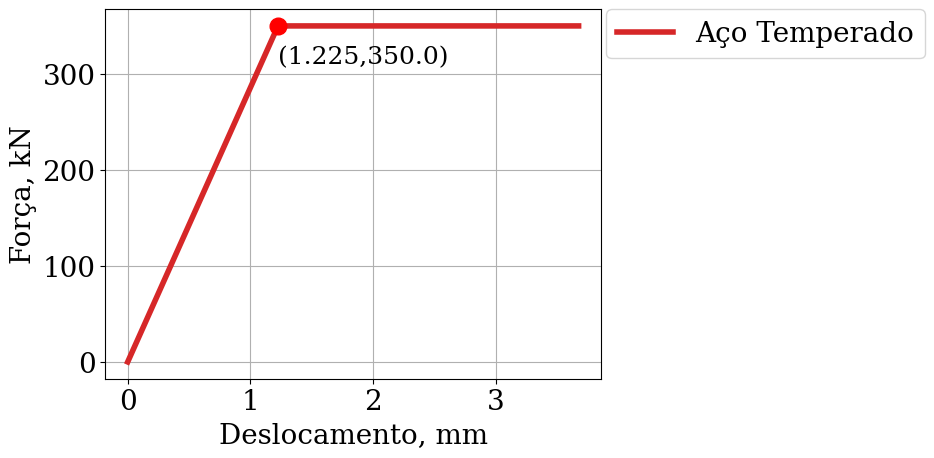

In [3]:
import matplotlib.pyplot as plt

plt.rcParams.update({'font.size': 20})
# use LaTeX fonts in the plot
# plt.rc('text', usetex=True)
plt.rc('font', family='serif')

FmaxaT = SigCaT*AaT
print(f'Fmax (aço temperado) = {FmaxaT*1e-3:.2f} kN')

DFmaxaT = FmaxaT*L/E/AaT
print(f'Desl. (aço temperado) (Fmax) = {DFmaxaT:.4f} mm')

def pFig(x,y,cor,leg):
    fig = plt.figure()
    ax = fig.add_subplot(1, 1, 1)
    ax.plot([0,x ,3*x], [0,y,y], color=cor, linewidth=4, label=leg)
    ax.plot([x], [y],marker='o',color='r',markersize=12)
    plt.text(x, y*.89, f'({x:.3f},{y})', fontsize=18)
    ax.legend(bbox_to_anchor=(1.01, 1), loc='upper left', borderaxespad=0)
    plt.xlabel('Deslocamento, mm'), plt.ylabel('Força, kN')
    plt.grid(), plt.show()

pFig(DFmaxaT,FmaxaT*1e-3,'tab:red','Aço Temperado')

- Diagrama força-deslocamento aço macio (2)

Fmax (aço macio) = 218.75 kN
Desl. (aço macio) (Fmax) = 0.6125 mm


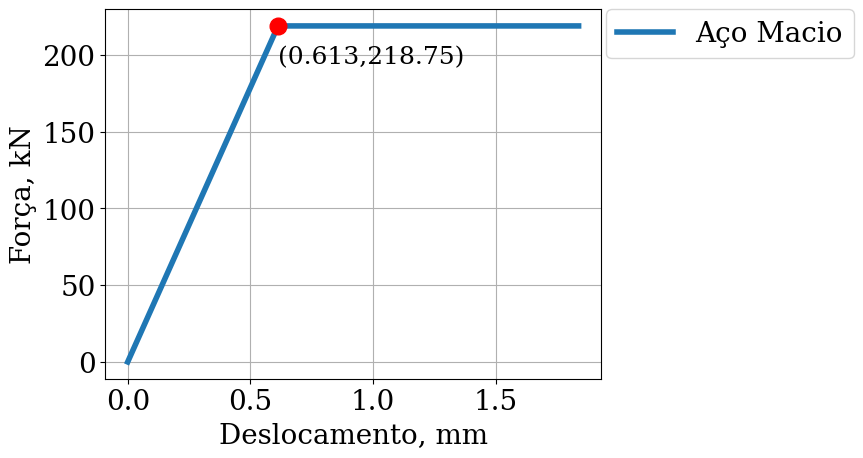

In [25]:
FmaxaM = SigCaM*AaM
print(f'Fmax (aço macio) = {FmaxaM*1e-3:.2f} kN')

DFmaxaM = FmaxaM*L/E/AaM
print(f'Desl. (aço macio) (Fmax) = {DFmaxaM:.4f} mm')

pFig(DFmaxaM,FmaxaM*1e-3,'tab:blue','Aço Macio')

- Diagrama força-deslocamento sobrepostos

Para a construção do diagrama força-deslocamento do material conjunto considere-se dois pontos (necessários para definir os segmentos de recta da lei de comportamento conjunta).

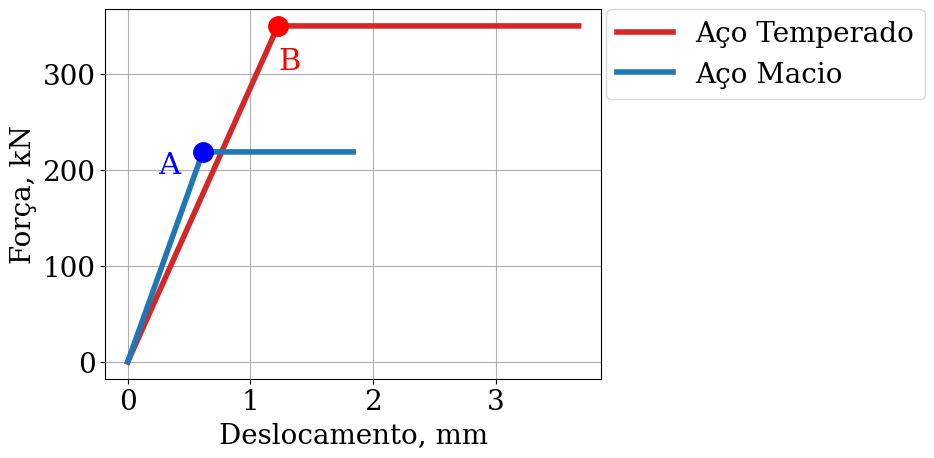

In [5]:
import numpy as np

mat1 = np.array([DFmaxaT,FmaxaT*1e-3])
mat2 = np.array([DFmaxaM,FmaxaM*1e-3])
fig = plt.figure()
ax = fig.add_subplot(1, 1, 1)
ax.plot([0,mat1[0] ,3*mat1[0]], [0,mat1[1],mat1[1]], color='tab:red',
        linewidth=4, label='Aço Temperado')
ax.plot([0,mat2[0] ,3*mat2[0]], [0,mat2[1],mat2[1]], color='tab:blue',
        linewidth=4, label='Aço Macio')
ax.plot([mat1[0]], [mat1[1]],marker='o',color='r',markersize=14)
plt.text(mat1[0]*1.0, mat1[1]*.87,'B',color='r',fontsize=22)
ax.plot([mat2[0]], [mat2[1]],marker='o',color='b',markersize=14)
plt.text(mat2[0]*.4, mat2[1]*.9,'A',color='b',fontsize=22)
# ax.plot([x], [y],marker='o',color='r',markersize=12)
# plt.text(x, y*.89, f'({x:.3f},{y})', fontsize=18)
ax.legend(bbox_to_anchor=(1.01, 1), loc='upper left', borderaxespad=0)
plt.xlabel('Deslocamento, mm')
plt.ylabel('Força, kN')
plt.grid()
plt.show()

_Ponto A (gráfico de conjunto)_

O ponto $A:(\delta_A, F_A$) cooresponde ao momento em que o material de aço macio (2) atinge o limite de elasticidde ou início de cedência:

- Deslocamento conjunto:
\begin{equation*}
\delta_A = \delta_1 = \delta_2 = 0.6125~\textrm{mm}
\end{equation*}

- Força conjunto:
\begin{equation*}
F_A = \sum_i F_i = F_1 + F_2 = F_1 + F_2^\mathrm{max}
= \frac{\delta_1EA_1}{L} + F_2^\mathrm{max}
= \frac{\delta_1EA_1}{L} + \sigma_{C_2}A_2
\end{equation*}

In [26]:
FA = FmaxaM + DFmaxaM*E*AaT/L
print(f'FA (aços temperado + macio) = {FA*1e-3:.2f} kN')

DA = DFmaxaM
print(f'Desl. (aços temperado + macio) = {DA:.4f} mm')

FA (aços temperado + macio) = 393.75 kN
Desl. (aços temperado + macio) = 0.6125 mm


_Ponto B (gráfico de conjunto)_

O ponto $B:(\delta_B, F_B$) cooresponde ao momento em que o material de aço temperado (1) entra em cedência:

- Deslocamento conjunto:
\begin{equation*}
\delta_B = \delta_1 = \delta_2 = 1.225~\textrm{mm}
\end{equation*}

- Força conjunto:
\begin{equation*}
F_B = \sum_i F_i = F_1 + F_2 = F_1^\mathrm{max} + F_2^\mathrm{max}
= \sigma_{C_1}A_1 +  \sigma_{C_2}A_2
\end{equation*}

- Diagrama força-deslocamento sobrepostos do conjunto (1+2)

FA (aços temperado + macio) = 568.75 kN
Desl. (aços temperado + macio) = 1.2250 mm


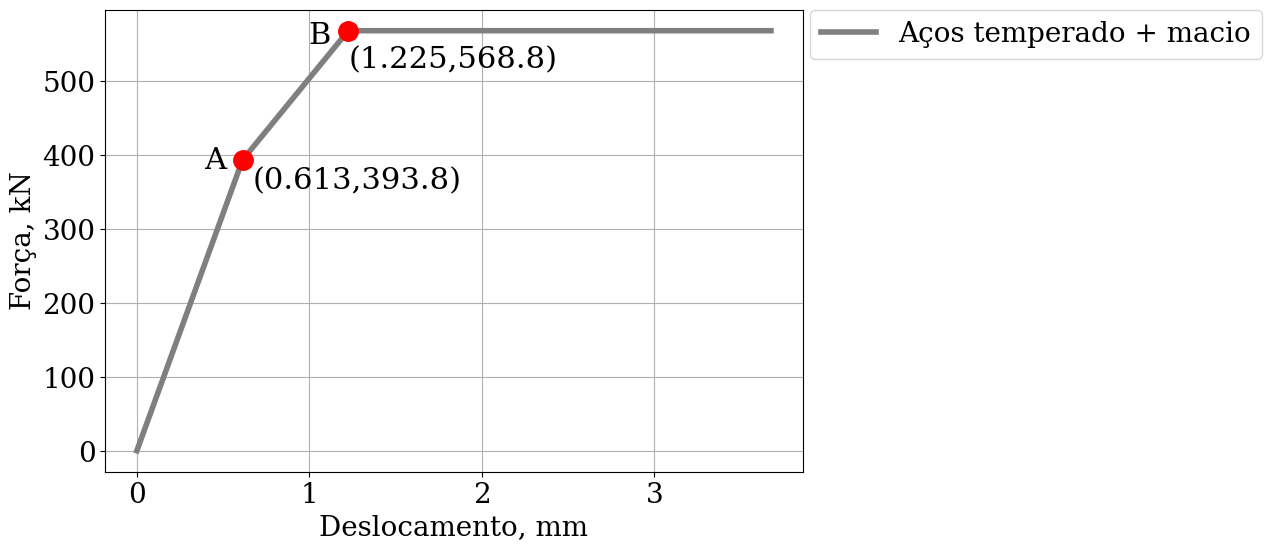

In [27]:
FB = FmaxaT + FmaxaM
print(f'FA (aços temperado + macio) = {FB*1e-3:.2f} kN')

DB = DFmaxaT
print(f'Desl. (aços temperado + macio) = {DB:.4f} mm')

xA, yA = DA, FA*1e-3
xB, yB = DB, FB*1e-3

fig = plt.figure(figsize=(9,6))
ax = fig.add_subplot(1, 1, 1)
st = 'Aços temperado + macio'
ax.plot([0,xA,xB,3*xB], [0,yA,yB,yB], color='tab:gray', linewidth= 4, label=st)
ax.plot([xA], [yA],marker='o',color='r',markersize=14)
plt.text(xA*1.1, yA*.9, f'({xA:.3f},{yA:3.1f})', fontsize=22)
plt.text(xA*.64, yA*.97, 'A', fontsize=22)
ax.plot([xB], [yB],marker='o',color='r',markersize=14)
plt.text(xB*1.0, yB*.91, f'({xB:.3f},{yB:3.1f})', fontsize=22)
plt.text(xB*.81, yB*.97, 'B', fontsize=22)
ax.legend(bbox_to_anchor=(1.01, 1), loc='upper left', borderaxespad=0)
plt.xlabel('Deslocamento, mm')
plt.ylabel('Força, kN')
plt.grid()
plt.show()

**Condições à forma máxima aplicada**

Para uma força máxima aplicada de $P=500$ MPa, pode verificar-se pelo gráfico anterior que o material 2 (aço macio) entrará em cedência (regima plástico); sendo contudo que o material 2 (aço temperado) permanece no regime elástico.

Esta verificação pode também obter-se considerando no domínio elástico o desenvolvimento da euquação de compatibilidade de deslocamentos:

\begin{equation*}
\begin{aligned}
\delta = \delta_1 &= \delta_2 \\
\frac{F_1 L}{A_1 E}  &= \frac{F_2 L}{A_2 E} \\
F_1 &= \frac{A_1}{A_2} F_2 = 0.8 F_2
\end{aligned}
\end{equation*}

Da equação de equilíbrio:

\begin{equation*}
\begin{aligned}
P = 0.8 F_2 + F_2
\quad\Leftrightarrow\quad
F_2 = \frac{P}{1.8}
\quad\wedge\quad
F_1 = 0.8F_2
\end{aligned}
\end{equation*}

In [8]:
from sympy.solvers import solve
from sympy import symbols

f1, f2 = symbols('f1 f2')

racioA = AaT/AaM
print(f'A1/A2 = {racioA:.1f}')
eq1 = f1 - racioA*f2
eq2 = P - f1 - f2

sol = solve([eq1,eq2],[f1,f2],)

calF1 = sol[f1]
print(f'F1 = {calF1*1e-3:4.2f} kN')
calF2 = sol[f2]
print(f'F2 = {calF2*1e-3:4.2f} kN')

A1/A2 = 0.8
F1 = 222.22 kN
F2 = 277.78 kN


De notar que as forças máximas de cedência dos materiais são:

In [9]:
F1ced = SigCaT*AaT
print(f'F1ced = {F1ced*1e-3:4.2f} kN (aço temperado)')

F2ced = SigCaM*AaM
print(f'F2ced = {F2ced*1e-3:4.2f} kN (aço macio)')

F1ced = 350.00 kN (aço temperado)
F2ced = 218.75 kN (aço macio)


Pelo que se conclui:

\begin{equation*}
F_1 < F_1^\textrm{ced}
\quad\wedge\quad
F_2 > F_2^\textrm{ced}
\end{equation*}

Logo o material (2) de aço macio entrará em plasticidade, para o nível de carga $P$ aplicada.

É importante identificar nesta curva força-deslocamento do conjunto a força aplicada $P$. Contudo, para a identificação das coordenadas deste ponto na curva $\delta_\textrm{max}$. é necessário determinar qual o alongamento (deslocamento) máximo à força $P$,

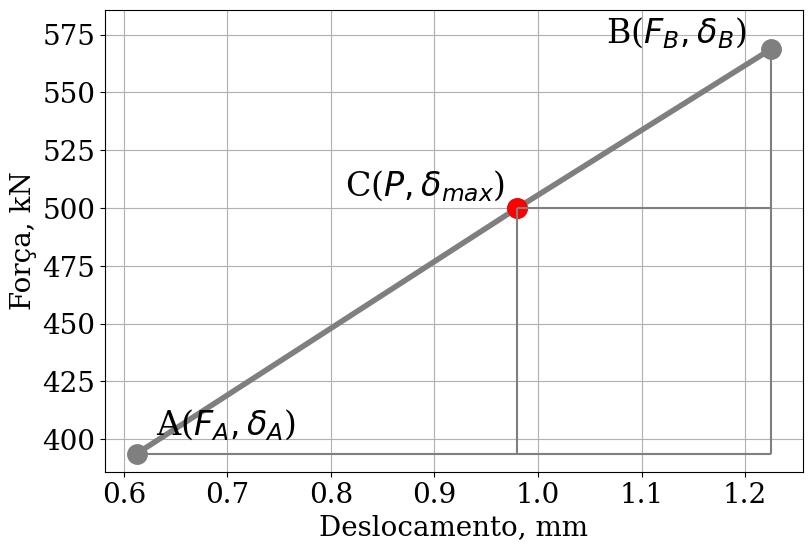

In [10]:
P1 = [xA, yA]
P2 = [0.98,P*1e-3]
P3 = [xB, yB]
fig = plt.figure(figsize=(9,6))
ax = fig.add_subplot(1, 1, 1)
ax.plot([P1[0],P2[0],P3[0]], [P1[1],P2[1],P3[1]], color='tab:gray',
        linewidth= 4, marker='o',markersize=14)
ax.plot(P2[0], P2[1],marker='o',color='r',markersize=14)
plt.text(P1[0]*1.03, P1[1]*1.02, r'A($F_A,\delta_A$)', fontsize=24)
plt.text(P2[0]*.83, P2[1]*1.01, r'C($P,\delta_{max}$)', fontsize=24)
plt.text(P3[0]*.87, P3[1]*1.005, r'B($F_B,\delta_B$)', fontsize=24)
plt.xlabel('Deslocamento, mm')
plt.ylabel('Força, kN')
plt.hlines(y = P1[1], xmin = P1[0], xmax = xB, color='tab:gray')
plt.hlines(y = P2[1], xmin = P2[0], xmax = P3[0], color='tab:gray')
plt.vlines(x = P2[0], ymin = P1[1], ymax = P2[1], color='tab:gray')
plt.vlines(x = P3[0], ymin = P1[1], ymax = P3[1], color='tab:gray')
plt.ylim(ymin = P1[1]*.98, ymax = P3[1]*1.03)
plt.grid()
plt.show()

Pela análise geométrica da semelhança de triangulos (entre os pontos $A$, $B$ e $C$), pode-se interpolar o seguinte valor para o deslocamento $\delta_\mathrm{max} (P)$;

\begin{equation*}
\frac{P-F_A}{\delta_\mathrm{max}-\delta_A} =
\frac{F_B-F_A}{\delta_B-\delta_A} =
\frac{F_B-P}{\delta_B-\delta_\mathrm{max}}
\end{equation*}

Resolvendo para $\delta_\mathrm{max}$:

\begin{equation*}
\delta_\mathrm{max} = \delta_A + \left(\frac{P-F_A}{F_B-F_A}\right)
(\delta_B - \delta_A)
= \delta_B - \left(\frac{F_B-P}{F_B-F_A}\right)
(\delta_B - \delta_A)
\end{equation*}

In [11]:
print('Aços temperado + macio:')
dmaxP = DA + (P-FA)/(FB-FA)*(DB-DA)
print(f'Desl. max (P) (tri 1) = {dmaxP:.4f}mm')
dmaxP2 = DB - (FB-P)/(FB-FA)*(DB-DA)
print(f'Desl. max (P) (tri 2) = {dmaxP2:.4f}mm')


Aços temperado + macio:
Desl. max (P) (tri 1) = 0.9844mm
Desl. max (P) (tri 2) = 0.9844mm


#### b) As tensões normais máximas nas barras. <a id="B"></a> ([_enunciatum_](#PIV102))

É de notar que para o nível de carregamento correspondente a $P$, o componente 2 (aço macio) entra no domínio plástico pelo que a força satura na força máxima à tensão de cedência do material:

**(2) ---> (1)**

\begin{equation*}
F_2 \equiv F_2^\mathrm{max}
~\Leftrightarrow~
\sigma_2 \equiv \sigma_{C} = 350~\textrm{MPa}
\end{equation*}

sendo pelo equilíbrio estático que a força no aço temperado (1) é,

\begin{equation*}
F_1 = P -  F_2^\mathrm{max}  = 281.25~\textrm{N}
~\Leftrightarrow~
\sigma_1 = \frac{F_1}{A_1} = 562.50~\textrm{MPa}
\end{equation*}

In [12]:
F1 = P - FmaxaM
print(f'F1 (P) = {F1*1e-3:.2f} kN')
S1 = F1/AaT
print(f'sigma 1 (P) = {S1:.2f} MPa')

F1 (P) = 281.25 kN
sigma 1 (P) = 562.50 MPa


**(1) ---> (2)**

O mesmo resultado poderia ser obtido considerando:

\begin{equation*}
F_1 = \delta_\mathrm{max}\frac{A_1E}{L} = 281,25~\textrm{N}
\quad\therefore\quad
\sigma_1 = \frac{F_1}{A} = 562,5~\textrm{MPa}
\end{equation*}

com, da equação de equilíbrio,

\begin{equation*}
F_2 = P - F_1 = 218,75~\textrm{N}
\quad\therefore\quad
\sigma_2 \equiv \sigma_{C} = 350~\textrm{MPa}
\end{equation*}

In [13]:
F1 = dmaxP*AaT*E/L
print(f'F1 (P) = {F1*1e-3:.2f} kN')
S1 = F1/AaT
print(f'sigma 1 (P) = {S1:.2f} MPa')
F2 = P - F1
print(f'F2 (P) = {F2*1e-3:.2f} kN')

F1 (P) = 281.25 kN
sigma 1 (P) = 562.50 MPa
F2 (P) = 218.75 kN


#### c) O alongamento residual do conjunto das três barras e as correspondentes tensões residuais. <a id="C"></a> ([_enunciatum_](#PIV102))

Considere-se o cenário da remoção da força aplicada $P$.

- Aço Temperado

    A força $F_1$ aplicada ao aço temperado (1) irá reduzir desde um valor: $F_1 =  P-F_2^\textrm{max}$ até zero. Esta porção do conjunto irá deformar no domínio elástica não sofrendo qualquer efeito de plasticidade.

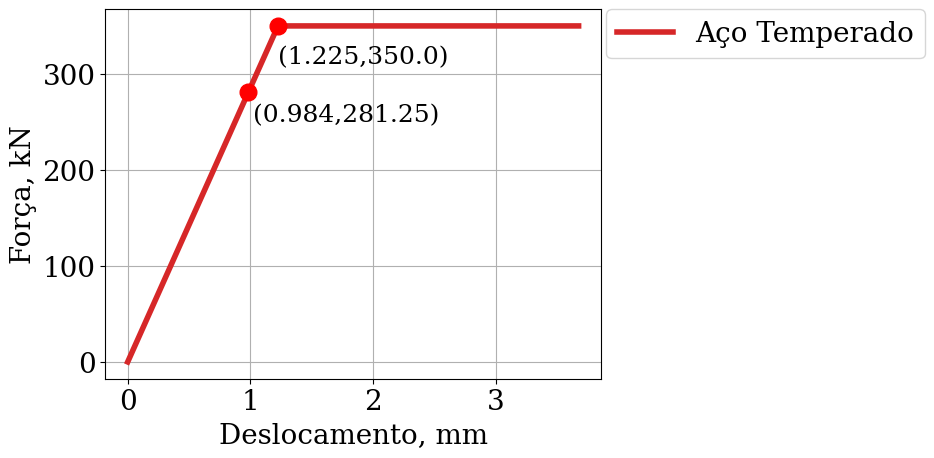

In [14]:
x, y = DFmaxaT, FmaxaT*1e-3
xf, yf = dmaxP, (P-FmaxaM)*1e-3
fig = plt.figure()
ax = fig.add_subplot(1, 1, 1)
ax.plot([0,x ,3*x], [0,y,y], color='tab:red', linewidth=4, label='Aço Temperado')
ax.plot(x, y,marker='o',color='r',markersize=12)
plt.text(x, y*.89, f'({x:.3f},{y})', fontsize=18)
ax.plot(xf, yf,marker='o',color='r',markersize=12)
plt.text(xf*1.04, yf*.89, f'({xf:.3f},{yf})', fontsize=18)
ax.legend(bbox_to_anchor=(1.01, 1), loc='upper left', borderaxespad=0)
plt.xlabel('Deslocamento, mm'), plt.ylabel('Força, kN')
plt.grid()
plt.show()

- Aço Macio

    A força $F_2$ aplicada ao aço maçio (2) irá reduzir desde um valor: $F_2^\textrm{max}$ até zero. Esta porção do conjunto irá deformar no domínio plástico. De acordo com o gráfico abaixo, a força desce ao longo do traço interrompido com o mesmo declive que o troço linear.

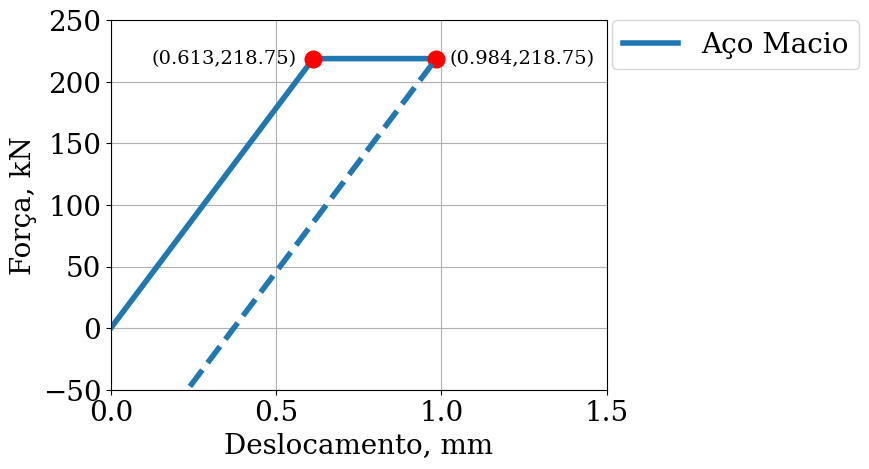

In [15]:
x, y = DFmaxaM, FmaxaM*1e-3
xf, yf = dmaxP, FmaxaM*1e-3
m = y/x
xr = dmaxP - x
fig = plt.figure()
ax = fig.add_subplot(1, 1, 1)
ax.plot([0,x ,dmaxP], [0,y,y], color='tab:blue', linewidth=4, label='Aço Macio')
ax.plot(x, y,marker='o',color='r',markersize=12)
plt.text(x*.2, y*.98, f'({x:.3f},{y})', fontsize=14)
ax.plot(xf, yf,marker='o',color='r',markersize=12)
ax.plot([xr/2, xr,xf], [yf+m*(xr/2-xf), 0,yf], color='tab:blue', linewidth=4,
        linestyle='--')
plt.text(xf*1.04, yf*.98, f'({xf:.3f},{yf})', fontsize=14)
ax.legend(bbox_to_anchor=(1.01, 1), loc='upper left', borderaxespad=0)
plt.xlabel('Deslocamento, mm'), plt.ylabel('Força, kN')
plt.xlim(0,1.5)
plt.ylim(-50,250)
plt.grid()
plt.show()

- Aço Temperado + Aço Macio

    No conjunto, a força aplicada $P$ irá decrescer ao longo de uma linha cujo declive é paralelo ao primeiro troço linear. O diagrama força-deslocamento do conjunto, incluindo ambos o carregamento e a descarga vem:

<img src="https://userweb.fct.unl.pt/~jmc.xavier/MSI/Notebooks/Au10/Au10_P002_i4.jpg"
width="700">

O deslocamento recuperado, $\delta\,{'}$, é dado por igualdade de triângulos:

\begin{equation*}
\frac{P}{\delta\,{'}} = \frac{F_A}{\delta_A}
\quad\therefore\quad
\delta\,{'} = -\frac{P}{F_A}\delta_A
\end{equation*}

O valor negativo indica retração da barra.

In [28]:
deltalinha = P/FA*DA
print(f'deltalinha = {- deltalinha:.4f} mm')

deltalinha = -0.7778 mm


Sendo o deslocamento residual dado por:

\begin{equation*}
\delta^R = \delta_\mathrm{max} - \delta'
\end{equation*}

In [17]:
dconj = dmaxP - deltalinha
print(f'Desl. residual do conjunto (versão 2) = {dconj:.4f} mm')

Desl. residual do conjunto (versão 2) = 0.2066 mm


O valor de deslocamento residual $\delta^R$ irá gerar tensões e forças aplicadas a dada secção de material.

A análise dos alongamentos e tensões residuais pode ser feita com base no diagrama força-deslocamento como ilustrado na
figura seguinte:

<img src="https://userweb.fct.unl.pt/~jmc.xavier/MSI/Notebooks/Au10/Au10_P002_i5.jpg"
width="650">

_Material (1) aço temperado_

Neste caso a força residual pode ser obtida por:

\begin{equation*}
F_1^R = F_1 \left(1 -
\frac{\delta_\mathrm{max}-\delta_R}{\delta_\mathrm{max}}\right)
\end{equation*}

In [18]:
Fr = symbols('Fr')
dr = dconj
eq1 = (F1-Fr)/(dmaxP - dr) - F1/dmaxP
sol = solve(eq1, Fr, dict=True)
Fres2 = float(sol[0][Fr])
print(f'(1) Fres = {Fres2:.2f} N')

Fres3 = F1*(1-(dmaxP-dr)/dmaxP)
print(f'(1) Fres (calc. 2) = {Fres3:.2f} N')

(1) Fres = 59027.78 N
(1) Fres (calc. 2) = 59027.78 N


_Material (2) aço macio_

Neste caso a força residual pode ser obtida por:

\begin{equation*}
F_2^R = F_2^\textrm{max}
\left(\frac{\delta_\mathrm{max}-\delta_R}{\delta_\mathrm{max}-\delta''} - 1
\right)
\end{equation*}

In [19]:
m = F2ced/DA
dx = dmaxP-F2ced/m
eq1 = (F2ced-Fr)/(dmaxP - dr) - F2ced/(dmaxP-dx)
sol = solve([eq1], [Fr], dict=True)
F2res2 = float(sol[0][Fr])
print(f'(2) Fres = {F2res2:.2f} N')

F2res3 = F2ced*(1-(dmaxP-dr)/(dmaxP-dx) )
print(f'(2) Fres (calc. 2) = {F2res3:.2f} N')

(2) Fres = -59027.78 N
(2) Fres (calc. 2) = -59027.78 N


De notar que pelo equilíbrio estático, uma vez que não existe qualquer força aplicada no final do ciclo de carga verifica-se:

\begin{equation*}
\sum F_y = 0 \Leftrightarrow F_1^R + F_2^R = 0
\Leftrightarrow F_2^R = - F_1^R
\quad\wedge\quad
F^R = |F_1^R| = |F_2^R|
\end{equation*}

**Método 2**

Para as forças envolvidas, a plastificação inicia na porção do material de aço macio (2). Neste material, a deformação plástica permanente será dada por:

\begin{equation*}
\delta_2^{p}
= \delta_\mathrm{max} - \delta_\mathrm{2}^{e}
\end{equation*}

In [20]:
deslplas = dmaxP - DFmaxaM
print(f'Desl. residual = {deslplas:.4f} mm')

Desl. residual = 0.3719 mm


Esta deformação permanente no mateial (2) irá contudo induzir uma deformação elástica no material (1).

Considere-se o esquema representado na figura seguinte. O aço macio (2) irá plastificar pelo que existirá um alongamentos permanente. O alongamento residual do conjunto irá contudo ser condicionado pelo comportamento elástico do material de aço temperado (1). O alongamento final será o deslocamento residual descontado do encurtamento elástico pela barra (1).

<img src="https://userweb.fct.unl.pt/~jmc.xavier/MSI/Notebooks/Au10/Au10_P002_i3.jpg"
width="600">

Pela compatibilidade de deslocamentos dos materiais em conjunto:

\begin{equation*}
\delta_{R} = \delta' + \delta''
= |\delta_1^{F_R}| + |\delta_2^{F_R}|
\Leftrightarrow
\delta_\mathrm{R}
= \frac{F_RL}{E} \left(\frac{1}{A_1} + \frac{1}{A_2}\right)
\Leftrightarrow
F_R = \frac{\delta_{R} E}{L\left(\frac{1}{A_1}+\frac{1}{A_2}\right)}
\end{equation*}

In [21]:
FRes = deslplas*E/L/(1/AaM+1/AaT)
print(f'Força residual = {FRes:.2f} N')

Força residual = 59027.78 N


Desta forma o alongamento residual do conjuto será:

\begin{equation*}
\delta_{conjunto} =
\delta^R - \delta_2^{F_R} =
\delta_1^{F_R}
= \frac{F^\mathrm{res} L }{A_1E}
\end{equation*}

In [22]:
deltaconjunto = FRes*L/AaT/E
print(f'Desl. residual do conjunto = {deltaconjunto:.4f} mm')

Desl. residual do conjunto = 0.2066 mm


**Tensões residuais: Método 1**

As tensões residuais vêm por sua vez, considerando as forças residuais instaladas:

\begin{equation*}
\begin{cases}
\sigma_1^R &= \displaystyle\frac{F_R}{A_1} \quad\textrm{(aço temperado)}\\
\sigma_2^R &= -\displaystyle\frac{F_R}{A_2} \quad\textrm{(aço macio)}
\end{cases}
\end{equation*}

In [23]:
s1res = FRes/AaT
print(f'Sigma 1 Res = {s1res:.2f} MPa (Tração)')

s2res = -FRes/AaM
print(f'Sigma 2 Res = {s2res:.2f} MPa (Compressão)')

Sigma 1 Res = 118.06 MPa (Tração)
Sigma 2 Res = -94.44 MPa (Compressão)


**Tensões residuais: Método 2**

A tensão instalada na força $P$ para cada material é (alínea b):

O mesmo resultado poderia ser obtido considerando:

\begin{equation*}
\sigma_1 = \frac{F_1}{A} = 562,5~\textrm{MPa}
\quad\wedge\quad
\sigma_2 \equiv \sigma_{C} = 350~\textrm{MPa}
\end{equation*}

Considerando a descarga como uma descarga equivalente no domínio elástico:

\begin{equation*}
\varepsilon' = \frac{\delta'}{L}
\quad\wedge\quad
\sigma_1' = E_1\varepsilon'
\quad\wedge\quad
\sigma_2' = E_2\varepsilon'
\end{equation*}

Pelo que as tensões residuais se obtêm por:

\begin{equation*}
\sigma_1^R = \sigma_1  - \sigma_1'
\quad\wedge\quad
\sigma_2^R = \sigma_2  - \sigma_2'
\end{equation*}

In [24]:
epslinha = deltalinha/L
print(f'eps = {epslinha:4.3e}')
s1linha = epslinha*E
print(f'sig = {s1linha:4.2f} MPa')
s1rediual = S1 - s1linha
print(f'sig residual (1) = {s1rediual:4.2f} MPa (aço temperado)')
s2linha = epslinha*E
s2rediual = SigCaM - s2linha
print(f'sig residual (1) = {s2rediual:4.2f} MPa (aço macio)')

eps = 2.222e-03
sig = 444.44 MPa
sig residual (1) = 118.06 MPa (aço temperado)
sig residual (1) = -94.44 MPa (aço macio)


---

Copyright (c) [Mecânica dos Sólidos I - DEMI - NOVA-SST]

Interactive computing by <a href="https://jupyter.org/" target="_blank"> <span
style="color:#333399"> Jupyter Notebook </span> </a> &nbsp;|&nbsp;Coded by <a href = "mailto: jmc.xavier@fct.unl.pt">José Xavier</a>

Licensed under  <a href="http://creativecommons.org/licenses/by-sa/4.0/"
target="_blank"> <span style="color:#333399;font-size: 20px"> CC BY-SA 4.0  </span></a>
